# Car Price Analysis Project
## Machine Learning Assignment 1

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/car_price.csv")
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,NaN,NaN,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,NaN,Like New,73577.10,Mustang


# Task 1: Exploratory Data Analysis

In [123]:
# shape of dataset (How many rows and columns does the dataset have?)

df.shape

(2500, 10)

In [124]:
#  Data Types and Feature Classification (Which features are numerical? Which are categorical? )

df.dtypes

Car ID            int64
Brand               str
Year              int64
Engine Size     float64
Fuel Type           str
Transmission        str
Mileage         float64
Condition           str
Price           float64
Model               str
dtype: object

From the output above, we can classify features into:

- Numerical features: columns with int or float values (e.g., price, year, mileage)
- Categorical features: columns with object type (e.g., fuel type, transmission)



In [125]:
#Missing Values (Are there any missing values? How many, and in which columns?)

df.isnull().sum()

Car ID            0
Brand             0
Year              0
Engine Size     175
Fuel Type       125
Transmission    150
Mileage         200
Condition       100
Price           125
Model            75
dtype: int64

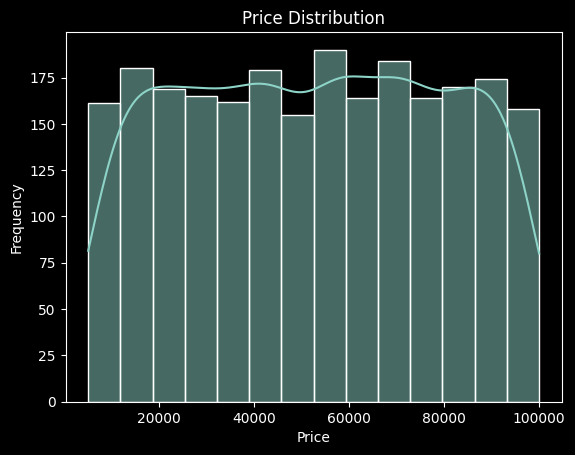

count     2375.000000
mean     52500.564118
std      27186.590166
min       5011.270000
25%      28980.710000
50%      53199.720000
75%      75556.900000
max      99982.590000
Name: Price, dtype: float64


In [126]:
#Price Distribution ( What does the distribution of car prices look like? )

sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print(df['Price'].describe())

The price distribution is approximately uniform, with cars spread fairly
evenly across all price ranges from ~$5,000 to ~$100,000.
The KDE curve is nearly flat with no significant skew.
Mean ≈ $52,500 and Median ≈ $53,200 are very close, confirming
a symmetric distribution with no dominant price range.

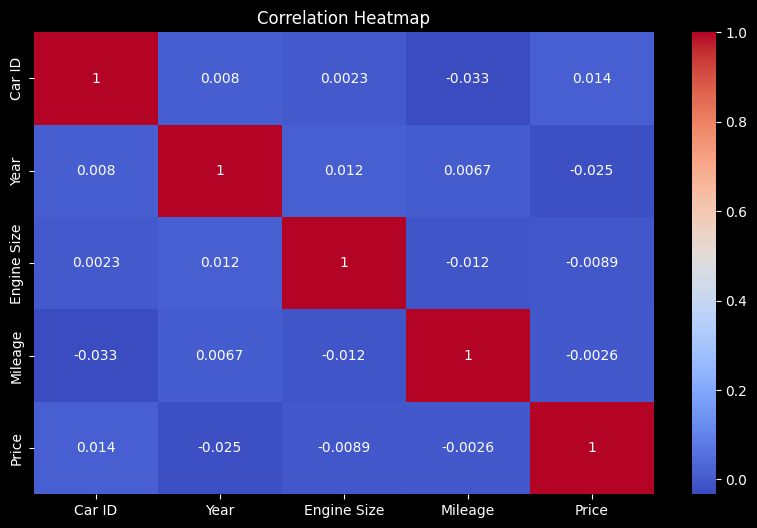

In [127]:
# Correlation Between Features (Which features seem most related to price? )

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 ### Relationship Between Price and Important Features

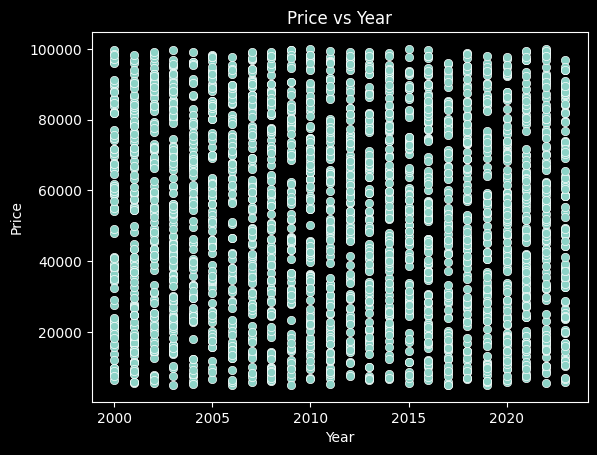

In [128]:
#Year
sns.scatterplot(x=df['Year'], y=df['Price'])
plt.title("Price vs Year")
plt.show()

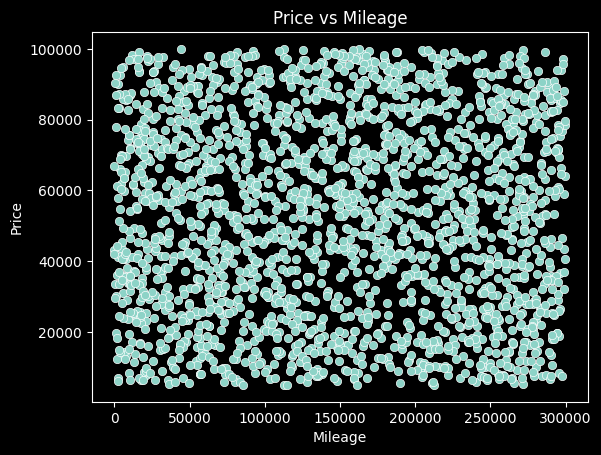

In [129]:
#Mileage
sns.scatterplot(x=df['Mileage'], y=df['Price'])
plt.title("Price vs Mileage")
plt.show()

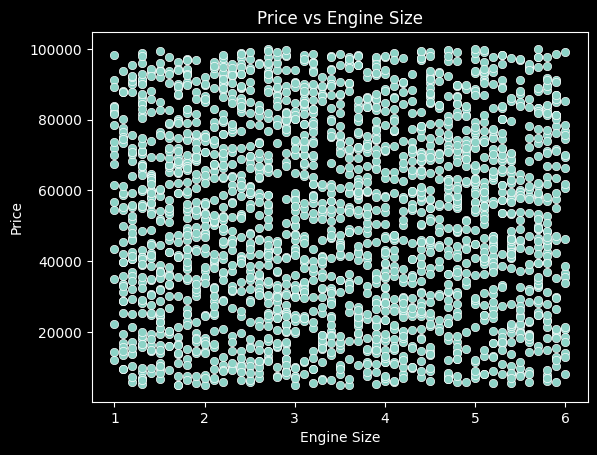

In [130]:
#Engine Size
sns.scatterplot(x=df['Engine Size'], y=df['Price'])
plt.title("Price vs Engine Size")
plt.show()

Based on correlation heatmap and visual analysis, all numerical features show very weak linear relationships with Price.

The strongest (but still weak) correlation is with Year (-0.0246), followed by Engine Size, Mileage, and Car ID.

This indicates that none of the numerical features individually have a strong linear impact on car price.

However, categorical features such as Brand, Condition, and Model are expected to have a much stronger influence on Price, as they represent major differences in car type, quality, and market value.

Therefore, the most related features to Price are mainly categorical rather than numerical in this dataset.

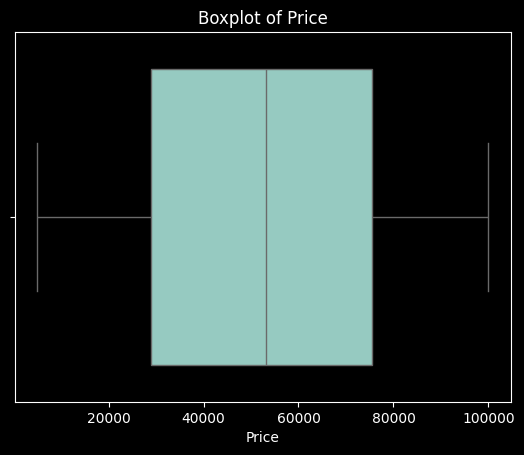

In [131]:
#Outlier Detection

sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")
plt.show()

# Task 2 : Data Preprocessing

**step 1 : Handling missing values**
1. Drop Row:
 - Price is the target variable , we can't have a row without price
  - Model has too many unique values to be a useful feature
2. Fill Nulls with:
 - Median: Mileage & Engine Size because median can't be affected by outliers
  - Mode: Categorical features : Fuel Type, Transmission and Condition

In [132]:
df_clean = df.copy()

df_clean.dropna(subset=['Price'], inplace = True)
df_clean.dropna(subset=['Model'], inplace=True)

df_clean['Engine Size'] = df_clean['Engine Size'].fillna(df_clean['Engine Size'].median())
df_clean['Mileage'] = df_clean['Mileage'].fillna(df_clean['Mileage'].median())

df_clean['Fuel Type'] = df_clean['Fuel Type'].fillna(df_clean['Fuel Type'].mode()[0])
df_clean['Transmission'] = df_clean['Transmission'].fillna(df_clean['Transmission'].mode()[0])
df_clean['Condition'] = df_clean['Condition'].fillna(df_clean['Condition'].mode()[0])

df_clean.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [133]:
df_clean.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,148940.0,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,148940.0,Like New,73577.10,Mustang


**step 2 : Detect and handle outliers**

In [134]:
numerical_cols = ['Year', 'Engine Size', 'Mileage']

for col in numerical_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]

    print(f'{col}: {len(outliers)} , outliers : bounds [{lower:.2f}, {upper:.2f}]')

    df_clean[col] = df_clean[col].clip(lower=lower , upper= upper)

Year: 0 , outliers : bounds [1988.00, 2036.00]
Engine Size: 0 , outliers : bounds [-1.15, 8.05]
Mileage: 0 , outliers : bounds [-137118.00, 433370.00]


No significant outliers detected after IQR analysis. Winsorization was applied as a safety step but had no effect on the data.

**step 3 : Encoding Categorical columns**

In [135]:
cat_cols_to_encode = ['Transmission', 'Brand', 'Fuel Type', 'Condition']

for col in cat_cols_to_encode:
    print(f"{col}: {df_clean[col].nunique()}")

Transmission: 2
Brand: 7
Fuel Type: 4
Condition: 3


**Label Encoding : Transmission**

Transmission has only 2 values (Manual & Automatic), so we use label encoding

In [136]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df_clean['Transmission'] = le.fit_transform(df_clean['Transmission'])


**One-Hot Encoding : Brand, Fuel Type, Condition**

These columns have no numeric order, so we create a separate binary column for each unique value

In [137]:
ohe_cols = ['Brand', 'Fuel Type', 'Condition']
enc      = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_array        = enc.fit_transform(df_clean[ohe_cols])
ohe_feature_names = enc.get_feature_names_out(ohe_cols)
ohe_df           = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=df_clean.index)

df_clean = pd.concat([df_clean.drop(columns=ohe_cols), ohe_df], axis=1)

print(f'Shape after encoding: {df_clean.shape}')
df_clean.head()

Shape after encoding: (2305, 21)


,Car ID,Year,Engine Size,Transmission,Mileage,Price,Model,Brand_Audi,Brand_BMW,Brand_Ford,...,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Diesel,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_Like New,Condition_New,Condition_Used
0,1,2016,2.3,1,114832.0,26613.92,Model X,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2,2018,4.4,1,148940.0,14679.61,5 Series,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3,2013,4.5,1,181601.0,44402.61,A4,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,2011,4.1,0,68682.0,86374.33,Model Y,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,2009,2.6,1,148940.0,73577.10,Mustang,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


**step 4 : Scale numerical features**

In [138]:
df_clean[['Year', 'Engine Size', 'Mileage']].describe().round(2)

,Year,Engine Size,Mileage
count,2305.00,2305.00,2305.00
mean,2011.70,3.47,148555.52
std,6.96,1.38,84688.54
min,2000.00,1.00,15.00
25%,2006.00,2.30,76815.00
50%,2012.00,3.40,148940.00
75%,2018.00,4.60,219437.00
max,2023.00,6.00,299854.00


In [139]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['Year', 'Engine Size', 'Mileage']
scaler     = StandardScaler()

df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print('After scaling:')
print(df_clean[scale_cols].describe().round(3))

After scaling:
           Year  Engine Size   Mileage
count  2305.000     2305.000  2305.000
mean      0.000        0.000    -0.000
std       1.000        1.000     1.000
min      -1.680       -1.787    -1.754
25%      -0.818       -0.846    -0.847
50%       0.043       -0.050     0.005
75%       0.905        0.818     0.837
max       1.624        1.832     1.787


## Preprocessing Summary

| Step | Action                                                            | Justification                                              |
|---|-------------------------------------------------------------------|------------------------------------------------------------|
| **Missing Values** | Drop Price/Model rows; Median for numerical; Mode for categorical | Target can't be imputed; Median isn't affected by outliers |
| **Outliers** | IQR + Winsorization                                               | Clips outliers to boundary values instead of removing rows |
| **Encoding** | Label for binary; One-Hot for nominal                             | Avoids false ordinal relationships                         |
| **Scaling** | StandardScaler on Year, Engine Size, Mileage                      | Required for KNN; Price excluded (it's the target)         |
